## Root-Finding Methods: Comparison Testing, Covergence, Efficiency, and Applications

### Objectives

This notebook investigates the performance of several classical root-finding algorithms for solving nonlinear equations.

 Methods examined:
- Bisection Method
- False Position Method
- Fixed Point Iteration
- Newton's Method
- Modified Newton's Method
- Secant Method
- Steffensen's Method

The goals are to:

- Compare convergence behavior.
- Measure computational efficiency.
- Verify theoretical convergence rates.
- Explore practical scientific applications.
- Investigate algorithm behavior on difficult problems.
- Analyze numerical error.

Background

Many scientific and engineering problems require solving equations of the form

$$f(x)=0$$

where an analytical solution may be unavailable or impractical.

Root-finding algorithms provide numerical approximations to these solutions and form a foundational component of scientific computing, simulation, optimization, and parameter estimation.

| Method          | Bracketing | Derivative Required | Theoretical Order  |
| --------------- | ---------- | ------------------- | ------------------ |
| Bisection       | Yes        | No                  | 1                  |
| False Position  | Yes        | No                  | 1                  |
| Fixed Point     | No         | No                  | 1                  |
| Newton          | No         | Yes                 | 2                  |
| Modified Newton | No         | Yes                 | 2 (multiple roots) |
| Secant          | No         | No                  | 1.618              |
| Steffensen      | No         | No                  | 2                  |


In [2]:
#Package Imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath("../..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from numerical_methods.root_finding import (
    bisection,
    false_position,
    fixed_point,
    modified_newton,
    newton,
    secant,
    steffensen)

from numerical_methods.utilities import (
    absolute_error,
    relative_error,
    compute_error_sequence,
    estimate_order_of_convergence,
    time_function,
    plot_error_history)

{'root': np.float64(0.7390851332151607), 'iterations': 4, 'converged': True, 'history': [np.float64(0.7280103614676171), np.float64(0.7390669669086738), np.float64(0.7390851331660756), np.float64(0.7390851332151607)]}


In [3]:
#Helper Functions

def run_method(
    method,
    method_name,
    true_root,
    *args,
    **kwargs):

    """
    Run a root-finding method and collect performance metrics.
    """

    #obtain results and computation time
    results, runtime = time_function(
        method,
        *args,
        **kwargs)

    #Evaluation Metrics
    final_error = absolute_error(true_root, results["root"])
    errors = compute_error_sequence(results["history"], true_root)
    orders = estimate_order_of_convergence(errors)

    return {"method":method_name,
            "root": results["root"],
            "iterations": results["iterations"],
            "runtime": runtime,
            "final_error": final_error,
            "history": results["history"],
            "errors": errors,
            "orders": orders}

def create_summary_table(results):
    """
    Create a comparison table from results
    """

    rows = []

    for i in results:
        if len(i["orders"]) >= 3:
            avg_order = np.mean(i["orders"][-3:])
        elif len(i["orders"]) > 0:
            avg_order = np.mean(i["orders"])
        else:
            avg_order = np.nan

        rows.append({
            "Method": i["method"],
            "Root": i["root"],
            "Iterations": i["iterations"],
            "Runtime (s)": i["runtime"],
            "Final Error": i["final_error"],
            "Observed Order": avg_order
        })
    return pd.DataFrame(rows)

    

### Problem A - Smooth Nonlinear Equation

Suppose $f(x) = 10 - 4x + np.sin(x)$

In [4]:
#Perform relative initial position finding with inefficient method - False Position

#Define Problem
def f(x):
    return 10 - 4 * x + np.sin(x)

#Define first derivative for Newton's Method
def df(x):
    return np.cos(x) - 4

#Define fixed point function for fixed-point iteration
def g(x): 
    return 10.0 / 4.0 + np.sin(x) / 4.0
    
"""
Perform initial guesses
    by the structure of the equation: p > 2  
    also, choose 5 as a suitable upper limit guess
"""

p0 = 2.0
p1 = 5.0

#Implementation
test_results = false_position(f, p0, p1)

numerical_results = secant(f, p0, p1, 1e-14)
true_root = numerical_results["root"]

"""
Now that x = 2, 5 are validated as good initial guesses, 
and a true root is estimated to a higher accuracy
implement root-finding comparison.
"""

#Initialize result storage
comparison_results = []

tol = 1e-10
bisect_results = run_method(bisection, "Bisection Method", true_root, f, p0, p1, tol=tol)
comparison_results.append(bisect_results)
false_position_results = run_method(false_position, "False Position", true_root, f, p0, p1, tol=tol)
comparison_results.append(false_position_results)
newtons_method_results = run_method(newton, "Newton's Method", true_root, f, df, p0, tol=tol)
comparison_results.append(newtons_method_results)
mod_newtons_results = run_method(modified_newton, "Modified Newton's Method", true_root, f, df, p0, 1, tol=tol)
comparison_results.append(mod_newtons_results)
secant_results = run_method(secant, "Secant Method", true_root, f, p0, p1, tol=tol)
comparison_results.append(secant_results)
steffensen_results = run_method(steffensen, "Steffensen's", true_root, g, p0, tol=tol)
comparison_results.append(steffensen_results)
fixed_point_iteration_results = run_method(fixed_point, "Fixed Point Iteration", true_root, g, p0, tol=tol)
comparison_results.append(fixed_point_iteration_results)

summary = create_summary_table(comparison_results)
display(summary)

,Method,Root,Iterations,Runtime (s),Final Error,Observed Order
0,Bisection Method,2.623751,35,0.000120,4.606804e-11,0.700214
1,False Position,2.623751,6,0.000014,5.329071e-15,1.375968
2,Newton's Method,2.623751,5,0.000017,0.000000e+00,2.103642
3,Modified Newton's Method,2.623751,4,0.000017,0.000000e+00,2.103642
4,Secant Method,2.623751,6,0.000011,0.000000e+00,1.554944
5,Steffensen's,2.623751,4,0.000014,0.000000e+00,NaN
6,Fixed Point Iteration,2.623751,16,0.000016,1.197487e-11,1.000003


#### Results

1. Steffensen's and Newton's method used fewest iterations,
2. Smallest final error was Newton's, modified Newtons, Secant, and Steffensen's
3. Fastest runtine was the Secant Method
4. The order of Steffensen converged so rapidly that insufficient pre-roundoff iterations remained to obtain a reliable convergence-order estimate. Also for the Bisection and False-Position Methods, the Error sequence was not in asymptotic regime / oscillatory and converged to machine precision too rapidly.

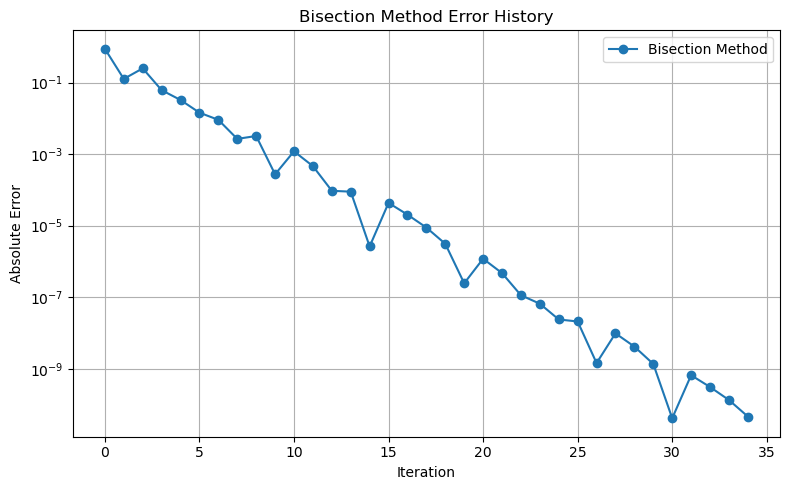

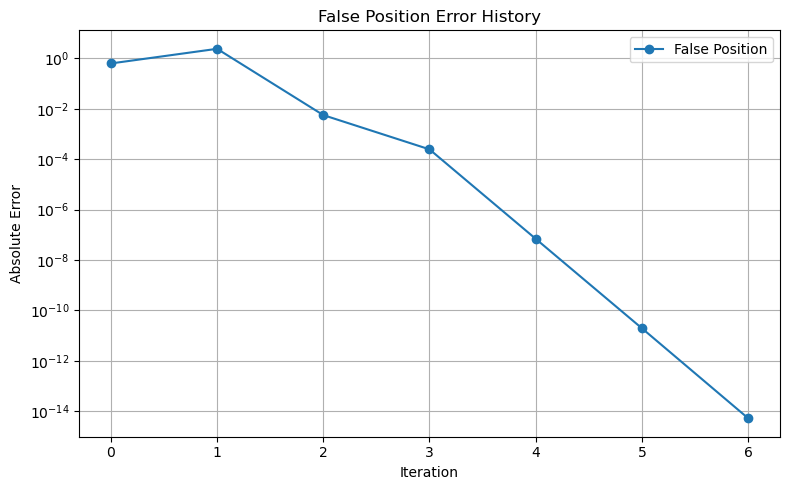

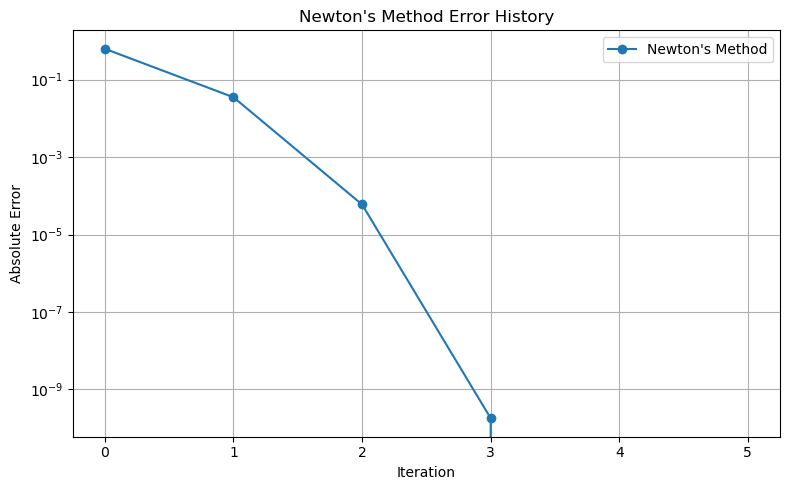

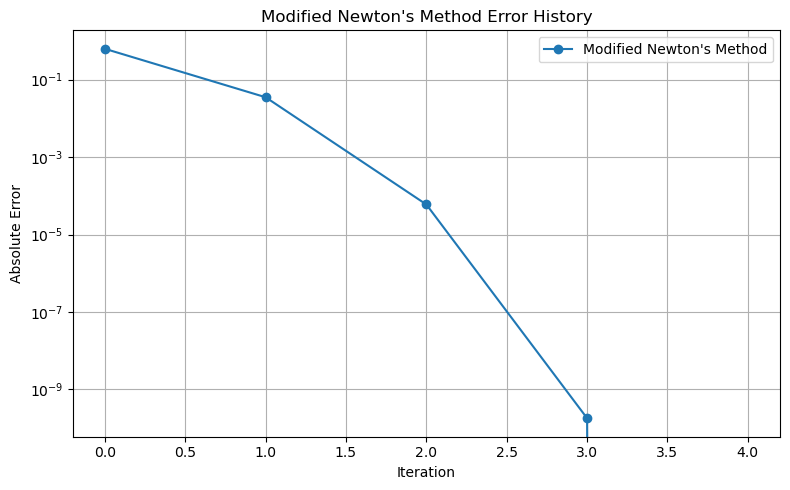

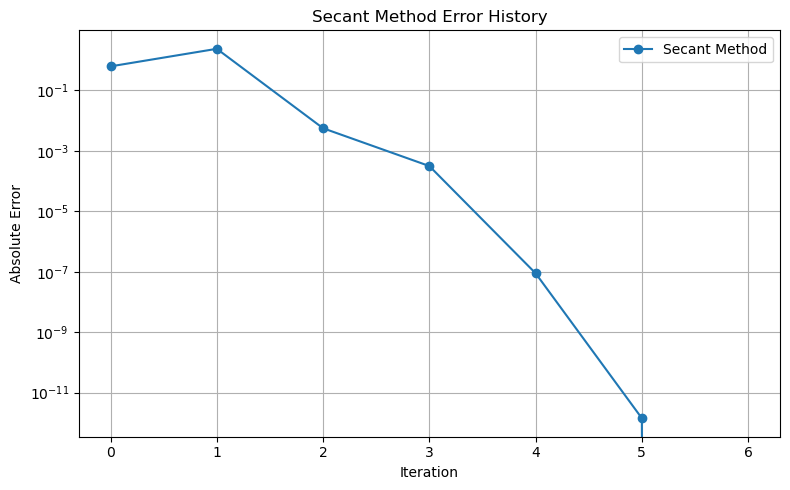

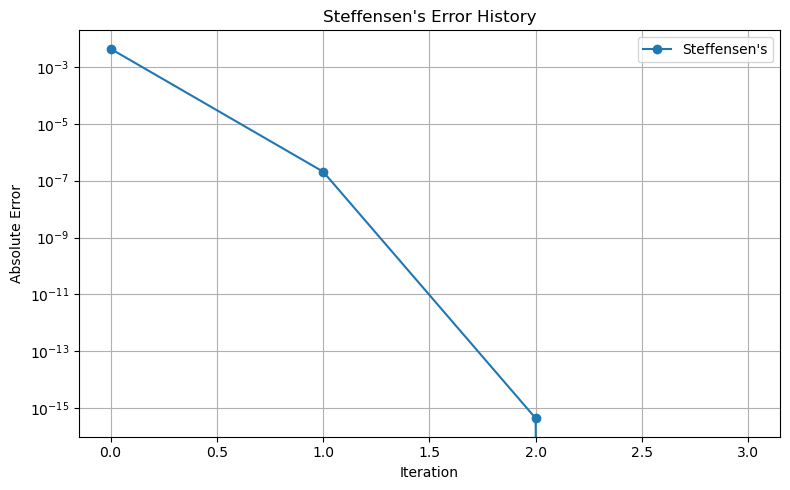

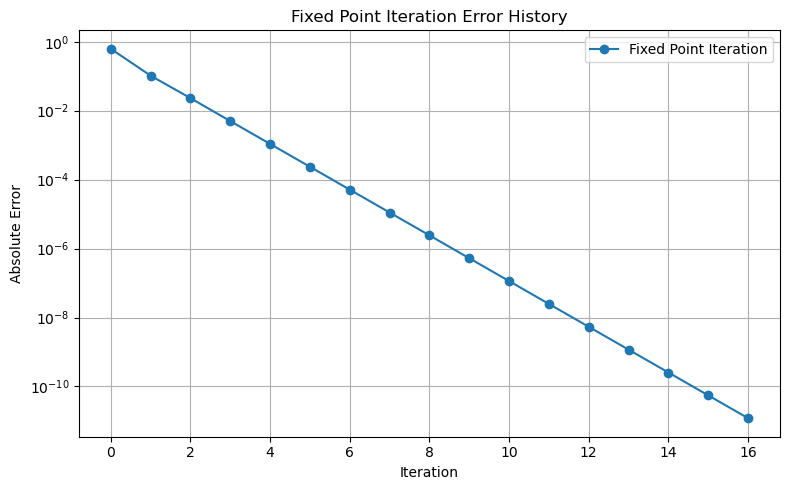

In [5]:
for i in comparison_results:
    plot_error_history(
        i["errors"],
        method_name=i["method"]
    )

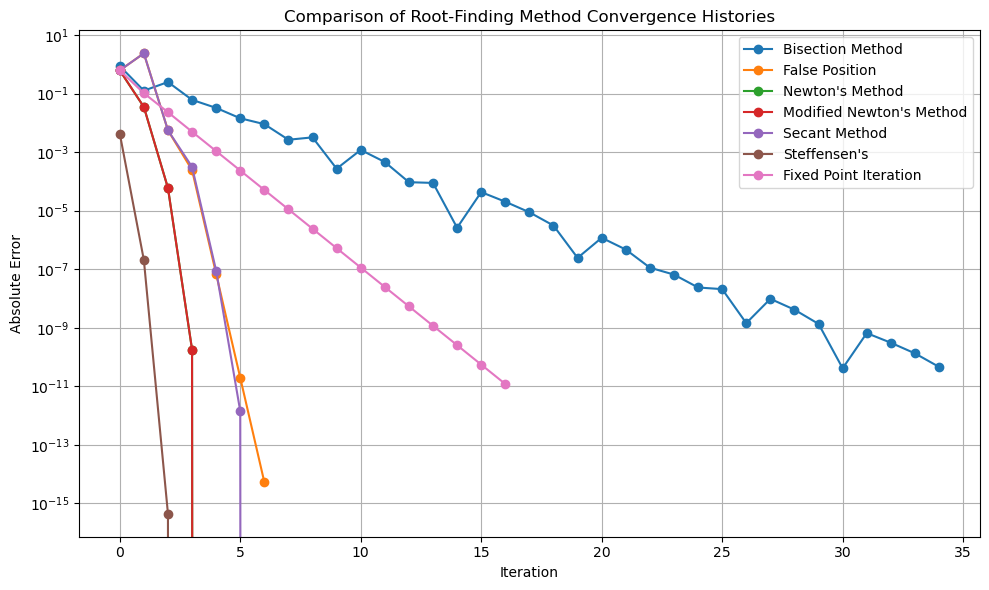

In [6]:
plt.figure(figsize=(10, 6))

for result in comparison_results:

    plt.semilogy(
        range(len(result["errors"])),
        result["errors"],
        marker="o",
        label=result["method"]
    )

plt.xlabel("Iteration")
plt.ylabel("Absolute Error")
plt.title("Comparison of Root-Finding Method Convergence Histories")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Results



#### Problem B - Population Growth Parameter Estimation

Suppose $1.564 \cdot (10^6) = 10^6 \cdot e^{\lambda} + 4.35 \cdot (10^5) \cdot\frac{e^{\lambda}-1}{\lambda}$

Define $F(\lambda) =  10^6 \cdot e^{\lambda} + 4.35 \cdot (10^5) \cdot\frac{e^{\lambda}-1}{\lambda} - 1.564 \cdot (10^6)$

Now we set $F(\lambda) = 0$

#### Problem C - Multiple Root Pathology

Suppose $f(x) = x^3 -3.8 x^2+4.77x-1.561$

#### Problem D - Fibbonacci's 1224 Challenge

Suppose $x^3+2x^2+10x-20=0$